# Load Data

In [9]:
TABLE = "price_features"
CALENDAR = "no_calendar"

In [10]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [11]:
import pandas as pd
import numpy as np
import duckdb

from src.config import (
    DATABASE_PATH,
    ROLLING_WINDOWS,
    LAGGED_WINDOWS,
    MA_WINDOWS,
    TICKERS,
    START_DATE,
    END_DATE
)

from src.features import (
    build_price_feature_columns
)

CALENDAR = "no_calendar"


def pull_calendar_table(table_name: str, calendar: str) -> pd.DataFrame:

    print("[START] Connecting to database...")

    con = duckdb.connect(DATABASE_PATH)

    print(f"[START] Reading {table_name}")

    df = con.sql(f"""
    
        SELECT *
        FROM {table_name}

    """).df()

    print(f"[DONE] Read {table_name}")

    con.close()

    print(f"[START] Building {CALENDAR} required columns...")

    base_cols = [
        "ticker",
        "date",
        "open",
        "high",
        "low",
        "close",
        "adj_close",
        "volume"
    ]

    feature_columns = build_price_feature_columns(
        calendars = [CALENDAR],
        rolling_windows = ROLLING_WINDOWS,
        lagged_windows = LAGGED_WINDOWS,
        ma_windows = MA_WINDOWS
    )

    expected_columns = base_cols + list(feature_columns.keys())

    calendar_df = df[expected_columns].copy()

    print(f"[DONE] Filtered to {CALENDAR}")

    calendar_df["date"] = pd.to_datetime(calendar_df["date"])

    calendar_df = calendar_df.sort_values(["ticker", "date"])

    print(f"[DONE] Prepared and sorted table")

    return calendar_df

In [12]:
df = pull_calendar_table(
    table_name = TABLE,
    calendar = CALENDAR
)

[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar
[DONE] Prepared and sorted table


In [13]:
df.columns

Index(['ticker', 'date', 'open', 'high', 'low', 'close', 'adj_close', 'volume',
       'daily_return_no_calendar', 'log_return_no_calendar',
       'cumulative_returns_no_calendar', 'rolling_7d_return_no_calendar',
       'rolling_30d_return_no_calendar', 'lag_1_return_no_calendar',
       'lag_5_return_no_calendar', 'moving_avg_20_no_calendar',
       'moving_avg_50_no_calendar', 'price_vs_ma20_no_calendar',
       'relative_volume_no_calendar', 'rolling_30d_volatility_no_calendar',
       'drawdown_no_calendar', 'target_next_day_return_no_calendar',
       'target_direction_no_calendar'],
      dtype='str')

In [42]:
table_count = 0
graph_count = 0
matrix_count = 0
figure_count = 0

# Feature Correlation with Target Next Day Return

In [15]:
df_1 = df.copy()

columns_to_keep = [
    column
    for column in df_1.columns
    if column == "ticker"
    or column.endswith(f"_{CALENDAR}")
]

df_1 = df_1[columns_to_keep]

df_1 = df_1.drop(columns=f"target_direction_{CALENDAR}", errors="ignore")

target = f"target_next_day_return_{CALENDAR}"

pearson = (
    df_1.corr(method="pearson", numeric_only=True)[target]
        .drop(target)
)

spearman = (
    df_1.corr(method="spearman", numeric_only = True)[target]
        .drop(target)
)

summary = (
    pd.DataFrame({
        "pearson":pearson,
        "spearman":spearman
    })
    .assign(
        max_absolute_correlation=lambda x:
            x[["pearson", "spearman"]].abs().max(axis=1)
    )
    .sort_values(
        "max_absolute_correlation",
        ascending=False
    )
)

table_count += 1
print(f"Table {table_count}: Global Pearson and Spearman Feature-Target Correlations")
display(summary.style.format(precision=3))

Table 1: Global Pearson and Spearman Feature-Target Correlations


,pearson,spearman,max_absolute_correlation
rolling_30d_volatility_no_calendar,0.074,0.018,0.074
rolling_30d_return_no_calendar,0.049,0.016,0.049
price_vs_ma20_no_calendar,0.027,-0.000,0.027
cumulative_returns_no_calendar,0.027,0.017,0.027
lag_5_return_no_calendar,-0.023,-0.010,0.023
drawdown_no_calendar,0.003,0.021,0.021
daily_return_no_calendar,-0.012,-0.018,0.018
log_return_no_calendar,-0.013,-0.018,0.018
rolling_7d_return_no_calendar,0.011,-0.010,0.011
lag_1_return_no_calendar,-0.009,-0.011,0.011


Pearson correlation measures linear relationship strength while Spearman correlation measures monotonic relationship strength meaning the tendency for two variables to go up but not necessarily in a linear pattern.

Globally, no features have meaningful standalone relationships with next day returns.

Small signals that high recent volatility is associated with higher returns, as well as slight signals of positive momentum with positive recent returns linked with positive returns.

In [16]:
target = f"target_next_day_return_{CALENDAR}"
ticker_column = "ticker"

pearson_by_ticker = pd.DataFrame({
    ticker_value: (
        group
        .corr(method="pearson", numeric_only=True)[target]
        .drop(target)
    )
    for ticker_value, group in df_1.groupby(ticker_column)
})

pearson_by_ticker = (
    pearson_by_ticker
    .rename_axis("variable")
    .reset_index()
    .assign(
        max_absolute_correlation=lambda x:
            x[pearson_by_ticker.columns].abs().max(axis=1),

        max_correlation_ticker=lambda x:
            x[pearson_by_ticker.columns].abs().idxmax(axis=1)
    )
    .sort_values(
        "max_absolute_correlation",
        ascending=False
    )
)

table_count += 1
print(f"Table {table_count}: Feature-Target Pearson Correlation by Ticker")

display(
    pearson_by_ticker.style
    .hide(axis="index")
    .format(precision=3)
)

Table 2: Feature-Target Pearson Correlation by Ticker


variable,GLD,MU,NKE,RPI.L,SNDK,SPY,TLT,max_absolute_correlation,max_correlation_ticker
daily_return_no_calendar,0.001,-0.047,-0.048,0.084,-0.016,-0.135,-0.016,0.135,SPY
log_return_no_calendar,0.002,-0.046,-0.050,0.080,-0.010,-0.135,-0.016,0.135,SPY
lag_5_return_no_calendar,-0.039,-0.046,-0.035,0.006,-0.023,-0.102,0.016,0.102,SPY
moving_avg_50_no_calendar,0.003,0.032,-0.020,-0.101,-0.088,-0.002,-0.019,0.101,RPI.L
lag_1_return_no_calendar,-0.042,0.027,0.018,-0.044,-0.086,0.079,-0.094,0.094,TLT
rolling_30d_volatility_no_calendar,-0.003,0.037,0.049,0.071,-0.010,0.038,0.006,0.071,RPI.L
relative_volume_no_calendar,-0.042,-0.002,-0.028,0.031,0.070,-0.019,-0.003,0.070,SNDK
moving_avg_20_no_calendar,0.006,0.030,-0.021,-0.067,-0.057,-0.003,-0.016,0.067,RPI.L
cumulative_returns_no_calendar,0.002,0.028,-0.026,-0.059,-0.062,-0.008,-0.022,0.062,SNDK
rolling_7d_return_no_calendar,-0.060,-0.009,-0.024,0.017,0.006,-0.030,-0.052,0.060,GLD


Across tickers, still generally weak correlations, although stronger relationships compared to global analysis.

SPY shows strongest very short term reversal trends with recent positive returns correlating slightly with negative target returns.

In [17]:
spearman_by_ticker = pd.DataFrame({
    ticker_value: (
        group
        .corr(method="spearman", numeric_only=True)[target]
        .drop(target)
    )
    for ticker_value, group in df_1.groupby(ticker_column)
})

spearman_by_ticker = (
    spearman_by_ticker
    .rename_axis("variable")
    .reset_index()
    .assign(
        max_absolute_correlation=lambda x:
            x[spearman_by_ticker.columns].abs().max(axis=1),

        max_correlation_ticker=lambda x:
            x[spearman_by_ticker.columns].abs().idxmax(axis=1)
    )
    .sort_values(
        "max_absolute_correlation",
        ascending=False
    )
)

table_count += 1
print(f"Table {table_count}: Feature-Target Spearman Correlation by Ticker")

display(
    spearman_by_ticker.style
    .hide(axis="index")
    .format(precision=3)
)

Table 3: Feature-Target Spearman Correlation by Ticker


variable,GLD,MU,NKE,RPI.L,SNDK,SPY,TLT,max_absolute_correlation,max_correlation_ticker
lag_1_return_no_calendar,-0.025,0.010,0.009,0.005,-0.094,-0.018,-0.044,0.094,SNDK
relative_volume_no_calendar,0.002,-0.003,-0.025,-0.020,0.068,0.007,-0.011,0.068,SNDK
moving_avg_50_no_calendar,0.032,0.019,-0.012,-0.058,-0.008,-0.012,-0.028,0.058,RPI.L
price_vs_ma20_no_calendar,-0.009,-0.020,-0.012,0.013,0.057,-0.035,-0.018,0.057,SNDK
rolling_30d_return_no_calendar,0.044,-0.001,0.001,0.010,0.048,-0.031,-0.001,0.048,SNDK
drawdown_no_calendar,0.035,-0.012,0.027,0.031,0.042,-0.043,-0.012,0.043,SPY
moving_avg_20_no_calendar,0.036,0.010,-0.015,-0.040,0.002,-0.015,-0.028,0.040,RPI.L
lag_5_return_no_calendar,0.007,-0.036,-0.006,0.019,-0.018,-0.023,0.012,0.036,MU
rolling_7d_return_no_calendar,-0.020,-0.011,-0.023,0.020,0.010,-0.036,-0.028,0.036,SPY
cumulative_returns_no_calendar,0.034,0.005,-0.020,-0.027,-0.008,-0.021,-0.034,0.034,TLT


Still weak signals but SNDK generally dominate showing the strongest spearman correlation signals. Shows momentum, trend, and mean reversion signals as moving average returns has positive correlations with target returns, positive relative volumne returns, but negative correlation with lag returns indicating that when previous recent days returns are high then the next day returns after tends to be lower.

Pearson evaluates linear relationship between variables making it more sensitive to outliers whiel Spearman compares monotonic relationship between ranks making it more resistant to outliers.

Spearman correlations between the engineered features and next-day returns are overwhelmingly negligible, with no consistent relationship across assets. The strongest result is a weak negative association between SNDK’s lagged return and its next-day return (ρ = −0.113), suggesting limited mean-reversion behaviour, while SNDK relative volume has a weak positive association (ρ = 0.088). Current daily and log returns are slightly negatively related to next-day returns for six of seven assets, but all coefficients remain below |0.05|, providing only minimal evidence of short-term reversal. Rolling returns, moving-average position, volatility, drawdown and cumulative-return features likewise show small and frequently mixed relationships. Comparison with Pearson correlations should determine whether these patterns are broadly linear or whether they are influenced by outliers, but the overall results indicate that individual technical features offer little standalone predictive power for next-day returns.

# Features vs Target Direction

In [18]:
df_2 = df.copy()

columns_to_keep = [
    column
    for column in df_2.columns
    if column == "ticker" or
    column.endswith(f"_{CALENDAR}")
]

df_2 = df_2[columns_to_keep]

df_2 = df_2.drop(columns=[f"target_next_day_return_{CALENDAR}"], errors="ignore")

target = f"target_direction_{CALENDAR}"

feature_avg = (
    df_2.groupby(target)
    .mean(numeric_only=True)
    .T
    .rename(columns={
        0: "down_avg",
        1: "up_avg"
    })
    .assign(
        difference = lambda x:
        x["up_avg"] - x["down_avg"]
    )
    .sort_values("difference", ascending=False)
)

table_count += 1
print(f"Table {table_count}: Global Comparison of Feature Means on Up vs Down Days")

display(
    feature_avg.style
        .format(precision=4)
)

feature_med = (
    df_2.groupby(target)
    .median(numeric_only=True)
    .T
    .rename(columns={
        0: "down_avg",
        1: "up_avg"
    })
    .assign(
        difference = lambda x:
        x["up_avg"] - x["down_avg"]
    )
    .sort_values("difference", ascending=False)
)

table_count += 1
print(f"Table {table_count}: Global Comparison of Feature Medians on Up vs Down Days")

display(
    feature_med.style
        .format(precision=4)
)

Table 4: Global Comparison of Feature Means on Up vs Down Days


target_direction_no_calendar,down_avg,up_avg,difference
moving_avg_50_no_calendar,196.9073,201.6798,4.7725
moving_avg_20_no_calendar,201.1007,205.6182,4.5175
cumulative_returns_no_calendar,1.0449,1.0654,0.0206
drawdown_no_calendar,-0.1842,-0.1707,0.0135
rolling_30d_return_no_calendar,0.0348,0.0369,0.0021
price_vs_ma20_no_calendar,0.0080,0.0081,0.0002
rolling_30d_volatility_no_calendar,0.0185,0.0184,-0.0001
lag_1_return_no_calendar,0.0011,0.0010,-0.0001
lag_5_return_no_calendar,0.0013,0.0009,-0.0004
rolling_7d_return_no_calendar,0.0075,0.0071,-0.0005


Table 5: Global Comparison of Feature Medians on Up vs Down Days


target_direction_no_calendar,down_avg,up_avg,difference
moving_avg_50_no_calendar,120.2536,123.3161,3.0625
moving_avg_20_no_calendar,120.6075,122.9568,2.3493
drawdown_no_calendar,-0.1176,-0.1000,0.0176
cumulative_returns_no_calendar,0.3521,0.3556,0.0035
rolling_30d_return_no_calendar,0.0107,0.0121,0.0014
lag_5_return_no_calendar,0.0006,0.0006,-0.0000
price_vs_ma20_no_calendar,0.0045,0.0043,-0.0002
lag_1_return_no_calendar,0.0007,0.0004,-0.0002
relative_volume_no_calendar,0.9205,0.9202,-0.0003
log_return_no_calendar,0.0008,0.0003,-0.0005


Globally, there is generally no difference in feature values when comparing up and down days. Moving averages of adjusted close may seem high but remember these are calculated in the real terms of the assets and are not very reliable since assets have varying prices.

In [19]:
target = f"target_direction_{CALENDAR}"
ticker="ticker"

for asset, group in df_2.groupby(ticker):
    feature_ticker_mean = (
    group.groupby(target)
    .mean(numeric_only=True)
    .T
    .rename(columns={
        0: "down_avg",
        1: "up_avg"
    })
    .assign(
        difference = lambda x:
        x["up_avg"] - x["down_avg"]
    )
    .sort_values("difference", ascending=False)
)

    table_count += 1
    print(f"Table {table_count}: {asset} Comparison of Feature Means on Up vs Down Days")

    display(
        feature_ticker_mean.style
            .format(precision=4)
    )

Table 6: GLD Comparison of Feature Means on Up vs Down Days


target_direction_no_calendar,down_avg,up_avg,difference
moving_avg_20_no_calendar,198.2931,200.8077,2.5147
moving_avg_50_no_calendar,197.9269,199.6938,1.7669
cumulative_returns_no_calendar,0.5888,0.6078,0.0190
drawdown_no_calendar,-0.0726,-0.0688,0.0037
rolling_30d_return_no_calendar,0.0151,0.0184,0.0033
lag_5_return_no_calendar,0.0004,0.0007,0.0002
rolling_30d_volatility_no_calendar,0.0098,0.0096,-0.0002
price_vs_ma20_no_calendar,0.0052,0.0047,-0.0004
rolling_7d_return_no_calendar,0.0042,0.0037,-0.0005
log_return_no_calendar,0.0008,0.0002,-0.0006


Table 7: MU Comparison of Feature Means on Up vs Down Days


target_direction_no_calendar,down_avg,up_avg,difference
relative_volume_no_calendar,0.9994,1.0204,0.0210
lag_1_return_no_calendar,0.0013,0.0024,0.0011
rolling_30d_volatility_no_calendar,0.0311,0.0311,0.0001
drawdown_no_calendar,-0.2279,-0.2290,-0.0012
lag_5_return_no_calendar,0.0028,0.0013,-0.0015
log_return_no_calendar,0.0027,0.0002,-0.0025
daily_return_no_calendar,0.0033,0.0008,-0.0025
rolling_7d_return_no_calendar,0.0152,0.0122,-0.0030
price_vs_ma20_no_calendar,0.0174,0.0130,-0.0044
rolling_30d_return_no_calendar,0.0682,0.0593,-0.0089


Table 8: NKE Comparison of Feature Means on Up vs Down Days


...

target_direction_no_calendar,down_avg,up_avg,difference
relative_volume_no_calendar,0.9888,1.0969,0.1082
price_vs_ma20_no_calendar,0.0906,0.1107,0.0201
rolling_30d_return_no_calendar,0.4752,0.4820,0.0069
log_return_no_calendar,0.0076,0.0115,0.0038
rolling_7d_return_no_calendar,0.0809,0.0846,0.0037
daily_return_no_calendar,0.0101,0.0136,0.0034
drawdown_no_calendar,-0.1445,-0.1424,0.0021
rolling_30d_volatility_no_calendar,0.0618,0.0601,-0.0017
lag_1_return_no_calendar,0.0158,0.0079,-0.0080
lag_5_return_no_calendar,0.0182,0.0084,-0.0098


Table 11: SPY Comparison of Feature Means on Up vs Down Days


target_direction_no_calendar,down_avg,up_avg,difference
moving_avg_20_no_calendar,412.1305,412.4874,0.3569
moving_avg_50_no_calendar,411.1401,411.2144,0.0743
drawdown_no_calendar,-0.0508,-0.0480,0.0028
lag_1_return_no_calendar,0.0002,0.0009,0.0007
rolling_30d_return_no_calendar,0.0174,0.0178,0.0004
rolling_30d_volatility_no_calendar,0.0104,0.0103,-0.0001
price_vs_ma20_no_calendar,0.0053,0.0049,-0.0003
lag_5_return_no_calendar,0.0008,0.0004,-0.0004
rolling_7d_return_no_calendar,0.0044,0.0038,-0.0006
log_return_no_calendar,0.0009,0.0003,-0.0006


Table 12: TLT Comparison of Feature Means on Up vs Down Days


target_direction_no_calendar,down_avg,up_avg,difference
drawdown_no_calendar,-0.2324,-0.2294,0.0029
rolling_30d_volatility_no_calendar,0.0090,0.0090,-0.0001
lag_5_return_no_calendar,0.0000,-0.0001,-0.0001
rolling_30d_return_no_calendar,-0.0004,-0.0008,-0.0005
daily_return_no_calendar,0.0003,-0.0003,-0.0006
log_return_no_calendar,0.0002,-0.0004,-0.0006
lag_1_return_no_calendar,0.0005,-0.0005,-0.0010
price_vs_ma20_no_calendar,0.0003,-0.0014,-0.0016
rolling_7d_return_no_calendar,0.0009,-0.0014,-0.0023
cumulative_returns_no_calendar,0.0274,0.0206,-0.0067


Genrally, feature separation between up and down days is generally small and inconsistent across assets.

There is no single feature that bahves consistently across assets supporting conclusions drawn when looking at comaprisons globally.

From the limited signals we do have we may be able to interpret the following:

GLD may exhibit weak short term reversal within a slightly positive longer term momentum environment, but the diffrences alone are likely to exhibit predictive power.

MU provides some evidence that stronger multi-day and monthly performance is followed by short term reversal, although the immediately lagged return and volume show a modest positive association with up days.

NKE displays possible one day mean reversion, with up days tending to follow a negative return. Higher relative volume appears mroe associated with subsequent down days.

RPI.L shows the clearest medium term momentum patterns. Up days generally occur during periods of strong recent momentum, higher volume and slightly greater volatility. However, current and immediately precending returns were higher before down days suggesting short term reversal within a broader momentum regime.

SNDK contains the largest mean differences but shoudl be interpreted carefully due to its shorter history. Relative volume was seen higher during up days, as well as price relative to moving average. LAgged returns indicate substatial reversal with higher lagged returns on down days comapred to up days.

SPY diaplys very little differences and separation. There is a weak suggestion of current day reversal, but most features appear unlikely to distinguish next day direction independently.

TLT shows reasonably consistent direction of short term reversal, but the absolute differences are small and probably insufficient for reliable next day classification.

These results provide some evidence of weak short-term mean reversion, especially in the current daily return. RPI.L shows a combination of medium-term momentum and immediate reversal, while SNDK shows potentially meaningful relationships with relative volume and lagged returns. TLT also has a relatively consistent, though small, reversal pattern.

Nevertheless, the differences are mostly small and vary substantially across assets. There is no universal feature that clearly separates next-day up and down movements. The tables therefore support the conclusion that next-day direction is highly noisy and difficult to predict using individual historical price and volume features alone.

They do not mean that the features are completely useless. Some may add value jointly, through nonlinear relationships or within asset-specific models, but the mean comparisons do not reveal a strong standalone predictor.

# Feature Return Correlation Heatmaps

Figure 2: Feature-Return Corrrelation Heatmaps


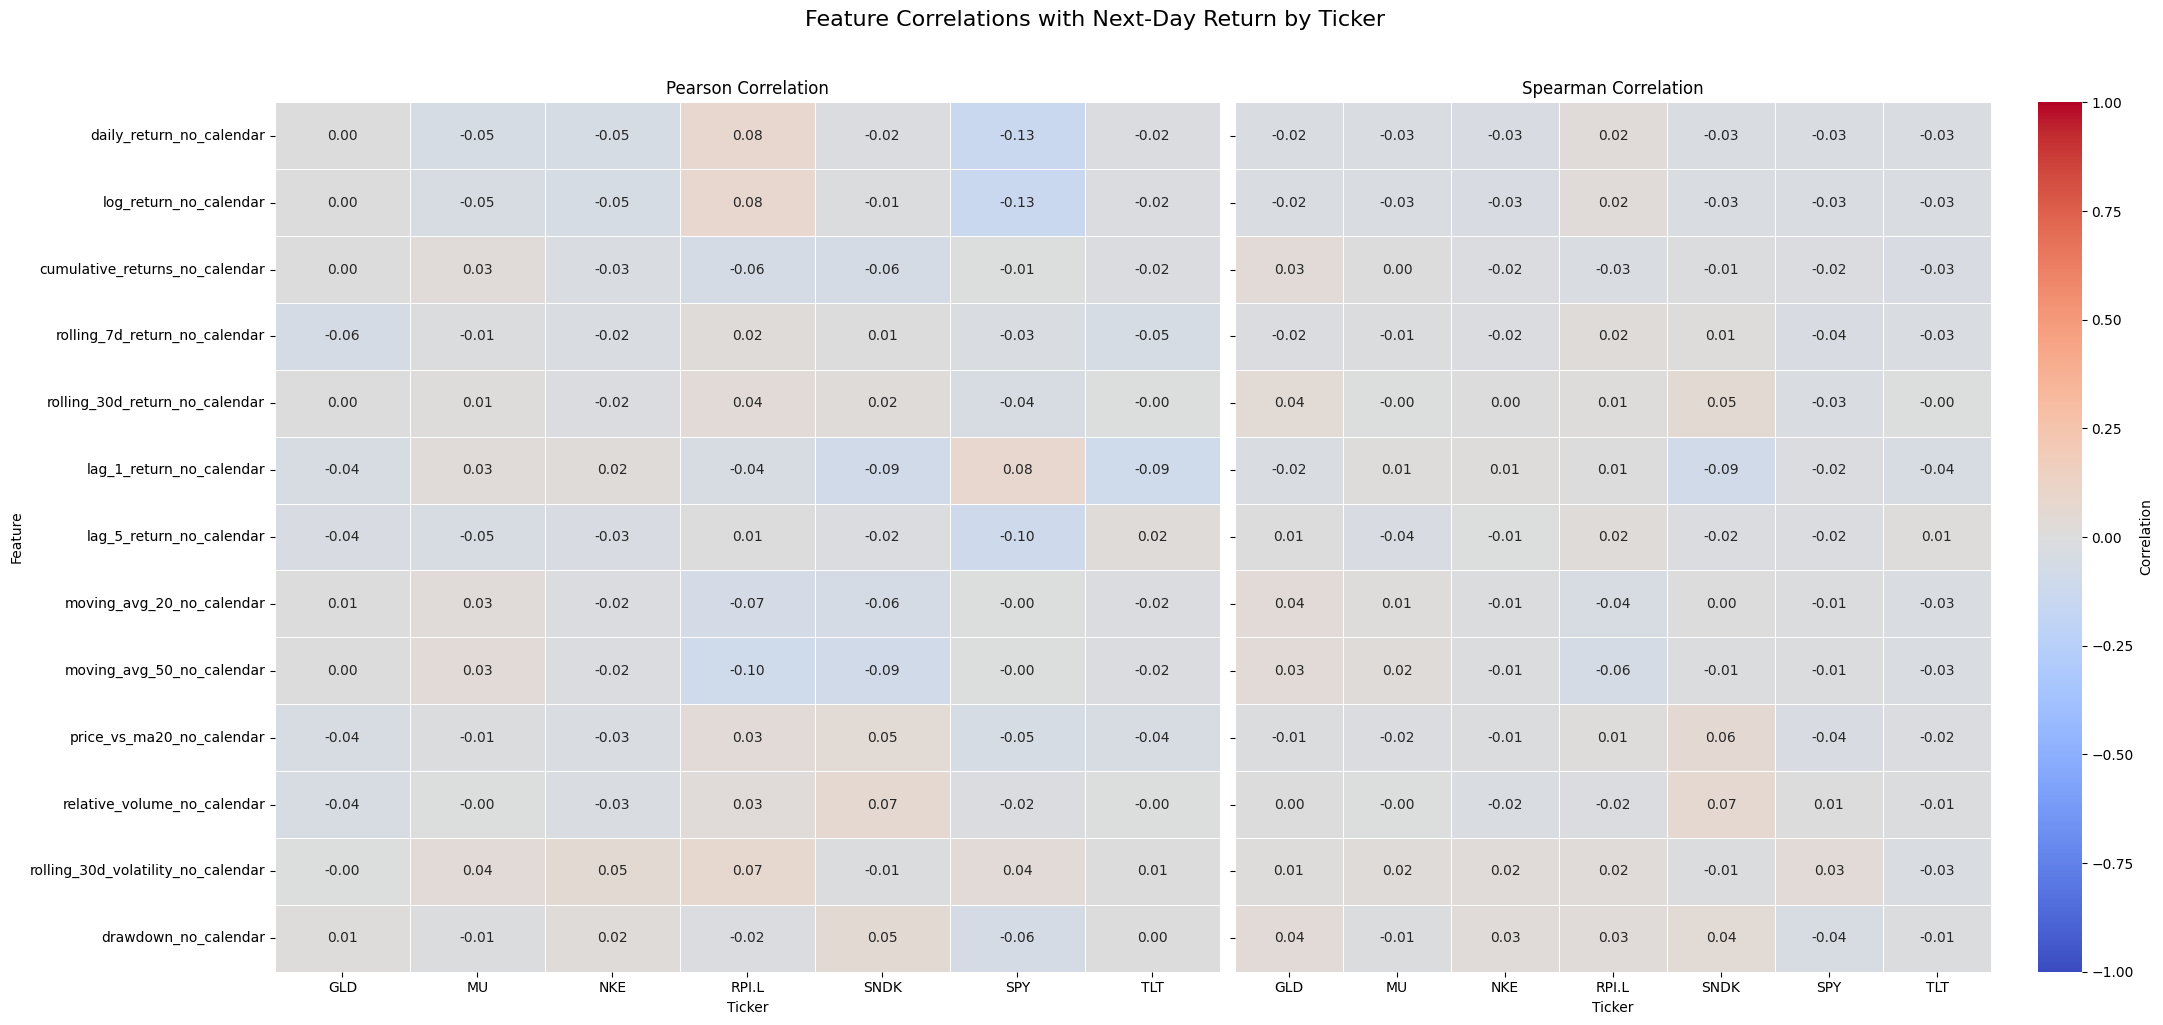

Table 2: Ranked Feature-Return Relationship Summary


variable,Median Absolute Pearson Correlation,Median Absolute Spearman Correlation,Max Absolute Correlation,Ticker Of Maximum,Positive Correlation Count,Negative Correlation Count
daily_return_no_calendar,0.05,0.03,0.13,SPY_pearson,3,11
log_return_no_calendar,0.05,0.03,0.13,SPY_pearson,3,11
cumulative_returns_no_calendar,0.03,0.02,0.06,SNDK_pearson,4,10
rolling_7d_return_no_calendar,0.02,0.02,0.06,GLD_pearson,4,10
rolling_30d_return_no_calendar,0.02,0.01,0.05,SNDK_spearman,8,6
lag_1_return_no_calendar,0.04,0.02,0.09,TLT_pearson,6,8
lag_5_return_no_calendar,0.03,0.02,0.10,SPY_pearson,5,9
moving_avg_20_no_calendar,0.02,0.01,0.07,RPI.L_pearson,5,9
moving_avg_50_no_calendar,0.02,0.02,0.10,RPI.L_pearson,4,10
price_vs_ma20_no_calendar,0.04,0.02,0.06,SNDK_spearman,4,10


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_1 = df.copy()

keep_colunmns = [
    column 
    for column in df_1.columns
    if column == "ticker" or column.endswith(f"_{CALENDAR}")
]

df_1 = df_1[keep_colunmns]
df_1 = df_1.drop(columns=[f"target_direction_{CALENDAR}"], errors="ignore")

target = f"target_next_day_return_{CALENDAR}"
ticker = "ticker"

pearson_corr = pd.DataFrame({
    ticker_value: (
        group
        .corr(method="pearson", numeric_only=True)[target]
        .drop(target)
        .rename_axis("variable")
        )
    for ticker_value, group in df_1.groupby(ticker)
})

spearman_corr = pd.DataFrame({
    ticker_value: (
        group
        .corr(method="spearman", numeric_only=True)[target]
        .drop(target)
        .rename_axis("variable")
        )
    for ticker_value, group in df_1.groupby(ticker)
})

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(22,10),
    sharey=True
)

sns.heatmap(
    pearson_corr,
    ax=axes[0],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar=False
)

axes[0].set_title("Pearson Correlation")
axes[0].set_xlabel("Ticker")
axes[0].set_ylabel("Feature")

sns.heatmap(
    spearman_corr,
    ax=axes[1],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

axes[1].set_title("Spearman Correlation")
axes[1].set_xlabel("Ticker")
axes[1].set_ylabel("")

fig.suptitle(
    "Feature Correlations with Next-Day Return by Ticker",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

figure_count += 1
print(f"Figure {figure_count}: Feature-Return Corrrelation Heatmaps")
plt.show()


combined_corr = pearson_corr.merge(
    spearman_corr,
    left_index = True,
    right_index = True,
    how = "inner"
)

combined_corr = combined_corr.rename(
    columns = lambda col: col.replace("_x", "_pearson").replace("_y", "_spearman")
)

combined_corr = (
    combined_corr
    .assign(
        max_absolute_corr = lambda x:
            x[combined_corr.columns].abs().max(axis=1),

        max_corr_ticker = lambda x:
            x[combined_corr.columns].abs().idxmax(axis=1),

        positive_corr_count = lambda x:
            x[combined_corr.columns].gt(0).sum(axis=1),

        negative_corr_count = lambda x:
            x[combined_corr.columns].lt(0).sum(axis=1)
    )
)

pearson_corr = (
    pearson_corr
    .assign(
        med_abs_pearson_corr = lambda x:
            x[pearson_corr.columns].abs().median(axis=1),
        )
    )

spearman_corr = (
    spearman_corr
    .assign(
        med_abs_spearman_corr = lambda x:
            x[spearman_corr.columns].abs().median(axis=1),
        )
    )

summary_df = pd.concat(
    [combined_corr[["max_absolute_corr", "max_corr_ticker", "positive_corr_count", "negative_corr_count"]], 
     pearson_corr[["med_abs_pearson_corr"]], 
     spearman_corr[["med_abs_spearman_corr"]]],
    axis=1,
    join="inner"
)

rename_map = {
    "max_absolute_corr": "Max Absolute\nCorrelation",
    "max_corr_ticker": "Ticker Of\nMaximum",
    "positive_corr_count": "Positive Correlation\n Count",
    "negative_corr_count": "Negative Correlation\n Count",
    "med_abs_pearson_corr": "Median Absolute\n Pearson Correlation",
    "med_abs_spearman_corr": "Median Absolute\n Spearman Correlation"
}

column_order = [
    "Median Absolute\n Pearson Correlation",
    "Median Absolute\n Spearman Correlation",
    "Max Absolute\nCorrelation",
    "Ticker Of\nMaximum",
    "Positive Correlation\n Count",
    "Negative Correlation\n Count"
]

summary_table = (
    summary_df
    .rename(columns=rename_map)
    .loc[:, column_order]
    .round(2)
    .reset_index()
)

count_cols = [
    "Positive Correlation\n Count",
    "Negative Correlation\n Count"
]

decimal_cols =[
    "Median Absolute\n Pearson Correlation",
    "Median Absolute\n Spearman Correlation",
    "Max Absolute\nCorrelation"
]

styled_table = (
    summary_table.style
    .format("{:.2f}", subset=decimal_cols)
    .format("{:.0f}", subset=count_cols)
    .set_table_styles([
        {
            "selector": "th.col_heading",
            "props": [
                ("white-space", "pre"),
                ("text-align", "right"),
                ("vertical-align", "middle"),
                ("min-width", "120px"),
            ],
        }
    ])
    .hide(axis="index")
)

table_count += 1
print(f"Table {table_count}: Ranked Feature-Return Relationship Summary")
styled_table


# Ranked Feature Return Relationship Summary

Figure 15: Directional-Separation Heatmap


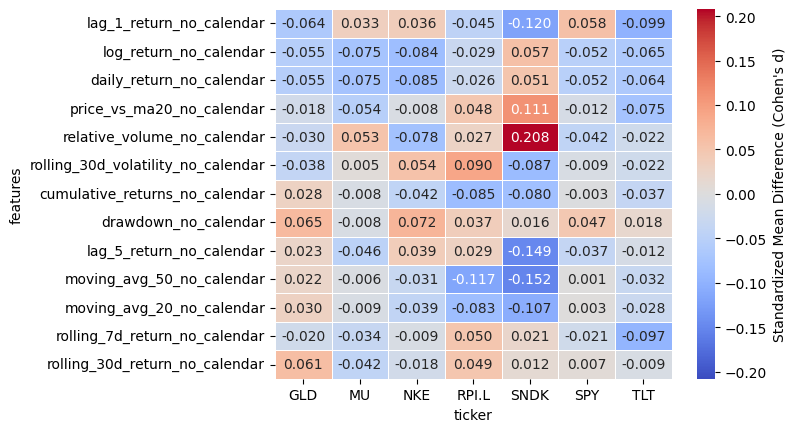

,features,median_abs_standardised_difference,median_signed_difference,maximum_abs_difference,ticker_of_maximum,consistent_sign_tickers,minimum_class_count
0,cumulative_returns_no_calendar,0.037373,-0.037373,0.084512,RPI.L,6,161
1,daily_return_no_calendar,0.054772,-0.054772,0.084555,NKE,6,161
2,drawdown_no_calendar,0.037223,0.037223,0.072089,NKE,6,161
3,lag_1_return_no_calendar,0.058307,-0.045260,0.119858,SNDK,4,161
4,lag_5_return_no_calendar,0.036585,-0.012200,0.149359,SNDK,4,159
5,log_return_no_calendar,0.057187,-0.054573,0.083978,NKE,6,161
6,moving_avg_20_no_calendar,0.030141,-0.028471,0.106954,SNDK,5,150
7,moving_avg_50_no_calendar,0.031339,-0.031339,0.151867,SNDK,5,134
8,price_vs_ma20_no_calendar,0.048380,-0.012045,0.111053,SNDK,5,150
9,relative_volume_no_calendar,0.041758,-0.022115,0.207971,SNDK,4,150


In [74]:
df_2 = df.copy()

target = f"target_direction_{CALENDAR}"
ticker = "ticker"

keep_columns = [
    column 
    for column in df_2.columns
    if column == ticker or column.endswith(f"_{CALENDAR}")
]

df_2 = df_2[keep_columns]
df_2 = df_2.drop(columns=[f"target_next_day_return_{CALENDAR}"], errors="ignore")

feature_columns = [
    column
    for column in df_2.columns
    if column.endswith(f"_{CALENDAR}") and column != target
]

results = []

for asset, ticker_df in df_2.groupby(ticker):

    down = ticker_df.loc[ticker_df[target] == 0, feature_columns]
    up = ticker_df.loc[ticker_df[target] == 1, feature_columns]

    down_mean = down.mean()
    up_mean = up.mean()

    down_median = down.median()
    up_median = up.median()

    diff_mean = up_mean - down_mean
    diff_median = up_median - down_median

    n_down = down.count()
    n_up = up.count()

    # Calculate variances using sample variance (n-1) rather than population variance (n)
    # Corrects for bias created / underestimation of varinace when sample is also used to calculate mean.
    down_var = down.var(ddof=1)
    up_var = up.var(ddof=1)

    # Calculate pooled standard deviation which gives insight into the natural spread in two groups.
    # Allows us to understand the magnitude of the difference in means relative to the natural spread of the data.
    pooled_std = np.sqrt(((n_down - 1) * down_var + (n_up - 1) * up_var) / (n_down + n_up - 2))

    # Use Cohens'd as standardised mean difference.
    cohens_d = diff_mean / pooled_std

    ticker_results = pd.DataFrame({
        "ticker": asset,
        "features": feature_columns,
        "down_mean": down_mean.values,
        "up_mean": up_mean.values,
        "down_median": down_median.values,
        "up_median": up_median.values,
        "diff_mean": diff_mean.values,
        "diff_median": diff_median.values,
        "n_down": n_down.values,
        "n_up": n_up.values,
        "standard_diff_mean": cohens_d.values,
        "n_up": n_up.values,
        "n_down": n_down.values,
    })

    results.append(ticker_results)

table = pd.concat(results, ignore_index=True)


directional_separation = table.pivot(
    index = "features",
    columns = "ticker",
    values = "standard_diff_mean"
)

feature_order = (
    directional_separation
    .abs()
    .median(axis=1)
    .sort_values(ascending=False)
    .index
)

directional_separation = directional_separation.loc[feature_order]

max_abs = table["standard_diff_mean"].abs().max().round(3)

sns.heatmap(
    directional_separation,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    vmin=-max_abs,
    vmax=max_abs,
    cbar_kws={"label": "Standardized Mean Difference (Cohen's d)"}
)

# Positive Cohens'd indicates that up mean is higher than down.
# Negative Cohens'd indicates that down mean is higher than up.
# Because calculated as (up_mean - down_mean) / pooled_std, the sign of the value indicates the direction of the difference.

figure_count += 1
print(f"Figure {figure_count}: Directional-Separation Heatmap")
plt.show()


summary_rows = []

for feature, feature_df in table.groupby("features"):

    # Cohen's d values for this feature across all tickers
    signed_d = feature_df["standard_diff_mean"]
    absolute_d = signed_d.abs()

    # Row containing the strongest absolute Cohen's d
    max_row_index = absolute_d.idxmax()
    max_row = feature_df.loc[max_row_index]

    # Smallest class available for each ticker
    ticker_min_counts = feature_df[["n_down", "n_up"]].min(axis=1)

    # Ignore exact zero values when checking direction
    non_zero_signs = np.sign(signed_d[signed_d != 0])

    if non_zero_signs.empty:
        consistent_sign_tickers = 0
  
    else:
        positive_count = (non_zero_signs > 0).sum()
        negative_count = (non_zero_signs < 0).sum()

        consistent_sign_tickers = max(
            positive_count,
            negative_count
        )

        

    summary_rows.append({
        "features": feature,

        # Typical strength, ignoring direction
        "median_abs_standardised_difference": absolute_d.median(),

        # Typical direction and strength
        "median_signed_difference": signed_d.median(),

        # Strongest result for this feature
        "maximum_abs_difference": absolute_d.max(),

        # Ticker where the strongest result occurred
        "ticker_of_maximum": max_row["ticker"],

        # Number of tickers pointing in the majority direction
        "consistent_sign_tickers": consistent_sign_tickers,

        # Smallest up/down sample across all tickers
        "minimum_class_count": ticker_min_counts.min()
    })

feature_summary = pd.DataFrame(summary_rows)

display(feature_summary)


# Directional Separation Heatmap

# Ranked Directional Separation Summary

# Up vs Non Positive Distributions

# Robustness Comparison